# 02 — Model Training

**Belgium Campus · Student Academic Risk Prediction**

> **Which model best predicts academic risk from anonymised BC student features?**

Programme/specialisation are context. Predictive power comes mainly from attendance, assignment completion, test/midyear averages, BC Connect activity, missed assessments, and failed modules.

---
## Project Overview

**Goal:** `Low` / `Medium` / `High` risk classification.  
**Leakage guards:** drop `student_id`, `profile`, `risk_score`.  
**Artefacts:** `models/trained_model.pkl`, `models/label_encoder.pkl`

---
## Import Libraries

In [11]:
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.svm import LinearSVC

RANDOM_STATE = 42
TEST_SIZE = 0.2
RISK_ORDER = ["Low", "Medium", "High"]
print("Libraries imported.")

Libraries imported.


---
## Load Dataset

In [12]:
NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR if (NOTEBOOK_DIR / "data").exists() else NOTEBOOK_DIR.parent
DATA_PATH = PROJECT_ROOT / "data" / "synthetic" / "students.csv"
MODEL_DIR = PROJECT_ROOT / "models"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(DATA_PATH)
print(f"Loaded {len(df):,} students")
display(df.head())

Loaded 2,000 students


,student_id,profile,age,gender,programme,specialisation,year_of_study,attendance,assignment_completion,bc_connect_activity,...,overall_average,midyear_average,test_average,assignment_average,practical_average,failed_modules,registered_modules,passed_modules,risk_score,risk_label
0,STU00001,average,28,Male,Bachelor of Information Technology,Software Development,Third Year,86,82,14,...,63.4,59.7,68.3,66.0,64.6,1,5,4,47.70,Medium
1,STU00002,thriving,22,Female,Bachelor of Computing,Software Engineering,First Year,95,96,24,...,84.6,85.3,84.7,91.2,84.2,0,5,5,11.02,Low
2,STU00003,thriving,20,Female,Higher Certificate in Information Systems,Information Systems,First Year,92,100,20,...,82.6,78.8,89.7,84.6,83.0,0,4,4,18.56,Low
3,STU00004,thriving,24,Male,Bachelor of Computing,Software Engineering,First Year,95,98,14,...,95.0,93.5,84.1,91.9,87.0,0,5,5,12.75,Low
4,STU00005,thriving,19,Non-binary,Higher Certificate in Information Systems,Information Systems,First Year,97,99,25,...,92.1,93.8,91.6,86.9,91.1,0,4,4,9.22,Low


---
## Feature Selection

In [13]:
LEAKAGE_OR_ID_COLS = ["student_id", "profile", "risk_score", "risk_label"]
feature_cols = [c for c in df.columns if c not in LEAKAGE_OR_ID_COLS]
X = df[feature_cols].copy()

categorical_features = ["programme", "specialisation", "gender", "year_of_study"]
numeric_features = [c for c in feature_cols if c not in categorical_features]

display(pd.DataFrame({"feature": feature_cols}))
print(f"Categorical: {categorical_features}")
print(f"Numeric:     {numeric_features}")

,feature
0,age
1,gender
2,programme
3,specialisation
4,year_of_study
5,attendance
6,assignment_completion
7,bc_connect_activity
8,missed_assessments
9,overall_average


Categorical: ['programme', 'specialisation', 'gender', 'year_of_study']
Numeric:     ['age', 'attendance', 'assignment_completion', 'bc_connect_activity', 'missed_assessments', 'overall_average', 'midyear_average', 'test_average', 'assignment_average', 'practical_average', 'failed_modules', 'registered_modules', 'passed_modules']


---
## Target Selection

In [14]:
y_raw = df["risk_label"].copy()
display(
    y_raw.value_counts().reindex(RISK_ORDER).rename("count").to_frame()
    .assign(percent=lambda d: (d["count"] / d["count"].sum() * 100).round(1))
)

,count,percent
risk_label,,
Low,708,35.4
Medium,702,35.1
High,590,29.5


---
## Encode Categorical Features

One-hot: `programme`, `specialisation`, `gender`, `year_of_study`.

In [15]:
label_encoder = LabelEncoder()
label_encoder.classes_ = np.array(RISK_ORDER)
y = y_raw.map({label: i for i, label in enumerate(RISK_ORDER)}).to_numpy()

display(pd.DataFrame({"risk_label": RISK_ORDER, "encoded": list(range(len(RISK_ORDER)))}))

preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", StandardScaler(), numeric_features),
    ]
)
print("Preprocessor ready.")

,risk_label,encoded
0,Low,0
1,Medium,1
2,High,2


Preprocessor ready.


---
## Train/Test Split

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)
display(
    pd.DataFrame(
        {
            "set": ["train", "test"],
            "n_students": [len(X_train), len(X_test)],
            "pct": [round(len(X_train) / len(X) * 100, 1), round(len(X_test) / len(X) * 100, 1)],
        }
    )
)

,set,n_students,pct
0,train,1600,80.0
1,test,400,20.0


---
## Feature Scaling

`StandardScaler` on numerics fits inside each pipeline on **train only**.

In [17]:
preprocess.fit(X_train)
Xt = preprocess.transform(X_train)
print(f"Transformed train shape: {Xt.shape}")
n_cat = preprocess.named_transformers_["cat"].get_feature_names_out().shape[0]
num_block = np.asarray(Xt[:, n_cat:])
display(
    pd.DataFrame(
        {
            "feature": numeric_features,
            "mean_after_scale": num_block.mean(axis=0).round(4),
            "std_after_scale": num_block.std(axis=0).round(4),
        }
    )
)

Transformed train shape: (1600, 35)


,feature,mean_after_scale,std_after_scale
0,age,-0.0,1.0
1,attendance,-0.0,1.0
2,assignment_completion,0.0,1.0
3,bc_connect_activity,0.0,1.0
4,missed_assessments,0.0,1.0
5,overall_average,0.0,1.0
6,midyear_average,-0.0,1.0
7,test_average,0.0,1.0
8,assignment_average,-0.0,1.0
9,practical_average,-0.0,1.0


---
## Train Multiple Models

In [18]:
candidates = {
    "Logistic Regression": LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
    "Linear SVC": LinearSVC(random_state=RANDOM_STATE, max_iter=5000),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
}

trained, rows = {}, []
for name, estimator in candidates.items():
    pipe = Pipeline([("preprocess", clone(preprocess)), ("model", estimator)])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1m = f1_score(y_test, y_pred, average="macro")
    trained[name] = {"pipeline": pipe, "y_pred": y_pred}
    rows.append({"model": name, "accuracy": round(acc, 4), "f1_macro": round(f1m, 4),
                 "f1_weighted": round(f1_score(y_test, y_pred, average="weighted"), 4)})
    print(f"Trained: {name:20s}  accuracy={acc:.4f}  f1_macro={f1m:.4f}")

results = pd.DataFrame(rows).sort_values("f1_macro", ascending=False).reset_index(drop=True)
display(results)

Trained: Logistic Regression   accuracy=0.9575  f1_macro=0.9598
Trained: Linear SVC            accuracy=0.9525  f1_macro=0.9550
Trained: Random Forest         accuracy=0.9425  f1_macro=0.9453
Trained: Gradient Boosting     accuracy=0.9475  f1_macro=0.9503


,model,accuracy,f1_macro,f1_weighted
0,Logistic Regression,0.9575,0.9598,0.9575
1,Linear SVC,0.9525,0.9550,0.9524
2,Gradient Boosting,0.9475,0.9503,0.9474
3,Random Forest,0.9425,0.9453,0.9421


---
## Compare Model Performance

Best model by **macro F1**.

Best model: Logistic Regression
              precision    recall  f1-score   support

         Low      0.970     0.908     0.938       142
      Medium      0.913     0.971     0.941       140
        High      1.000     1.000     1.000       118

    accuracy                          0.958       400
   macro avg      0.961     0.960     0.960       400
weighted avg      0.959     0.958     0.957       400



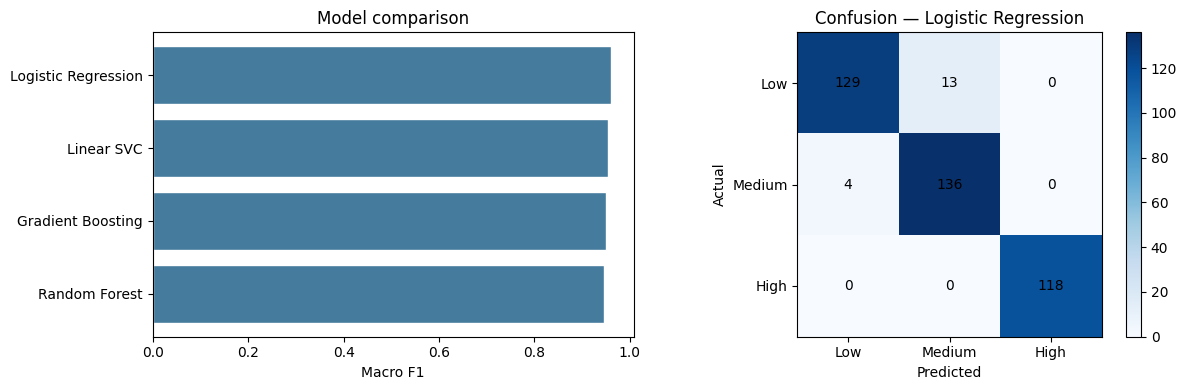

In [19]:
best_name = results.iloc[0]["model"]
best_pipe = trained[best_name]["pipeline"]
best_pred = trained[best_name]["y_pred"]

print(f"Best model: {best_name}")
print(classification_report(y_test, best_pred, target_names=list(label_encoder.classes_), digits=3))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].barh(results["model"], results["f1_macro"], color="#457b9d", edgecolor="white")
axes[0].invert_yaxis()
axes[0].set_xlabel("Macro F1")
axes[0].set_title("Model comparison")

order_idx = [list(label_encoder.classes_).index(r) for r in RISK_ORDER]
cm = confusion_matrix(y_test, best_pred, labels=order_idx)
im = axes[1].imshow(cm, cmap="Blues")
axes[1].set_xticks(range(3), RISK_ORDER)
axes[1].set_yticks(range(3), RISK_ORDER)
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")
axes[1].set_title(f"Confusion — {best_name}")
for i in range(3):
    for j in range(3):
        axes[1].text(j, i, cm[i, j], ha="center", va="center")
fig.colorbar(im, ax=axes[1], fraction=0.046)
plt.tight_layout()
plt.show()

---
## Save Best Model

In [20]:
model_path = MODEL_DIR / "trained_model.pkl"
encoder_path = MODEL_DIR / "label_encoder.pkl"
joblib.dump(best_pipe, model_path)
joblib.dump(label_encoder, encoder_path)
assert np.array_equal(joblib.load(model_path).predict(X_test), best_pred)
display(pd.DataFrame({
    "artefact": ["trained_model.pkl", "label_encoder.pkl"],
    "path": [str(model_path), str(encoder_path)],
}))
print("Saved and reload-verified.")

,artefact,path
0,trained_model.pkl,c:\Users\bemab\OneDrive\Desktop\AIN-Project\bc...
1,label_encoder.pkl,c:\Users\bemab\OneDrive\Desktop\AIN-Project\bc...


Saved and reload-verified.
